In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

In [3]:
shap.initjs()

In [4]:
model = joblib.load("../models/churn_model.pkl")

In [5]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [6]:
X_train_processed = joblib.load("../data/processed/X_train_processed.pkl")
X_test_processed = joblib.load("../data/processed/X_test_processed.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

In [7]:
feature_names = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]

X_train_processed = pd.DataFrame(
    X_train_processed.toarray(),
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed.toarray(),
    columns=feature_names
)

print(f"Total processed features: {len(feature_names)}")
print("\nFirst 10 feature names:")
print(feature_names[:10])

Total processed features: 1172

First 10 feature names:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'City_Acampo', 'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills', 'City_Aguanga', 'City_Ahwahnee']


In [8]:
explainer = shap.TreeExplainer(model)

In [9]:
shap_values = explainer(X_test_processed)

In [10]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [11]:
print(shap_values.values.shape)

(1407, 1172)


In [12]:
print(shap_values.values[0])

[-0.7237946  -0.13247006 -0.34961155 ... -0.02724468  0.17354615
 -0.0390401 ]


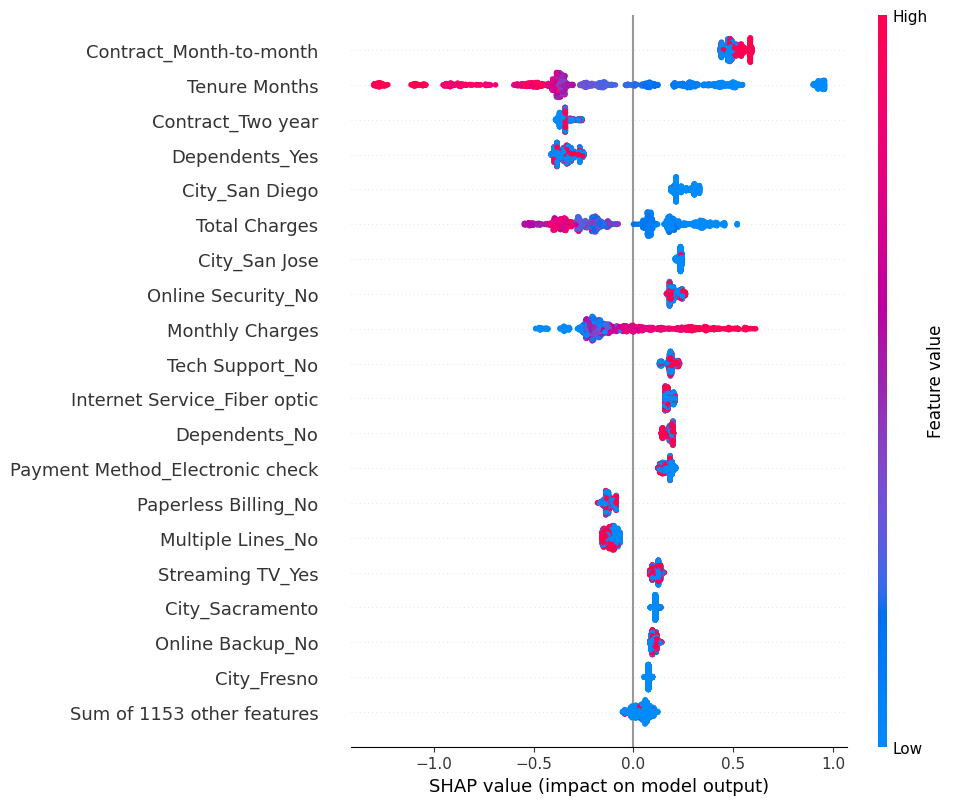

In [13]:
plt.figure(figsize=(12, 8))

shap.plots.beeswarm(shap_values, max_display=20)

plt.show()

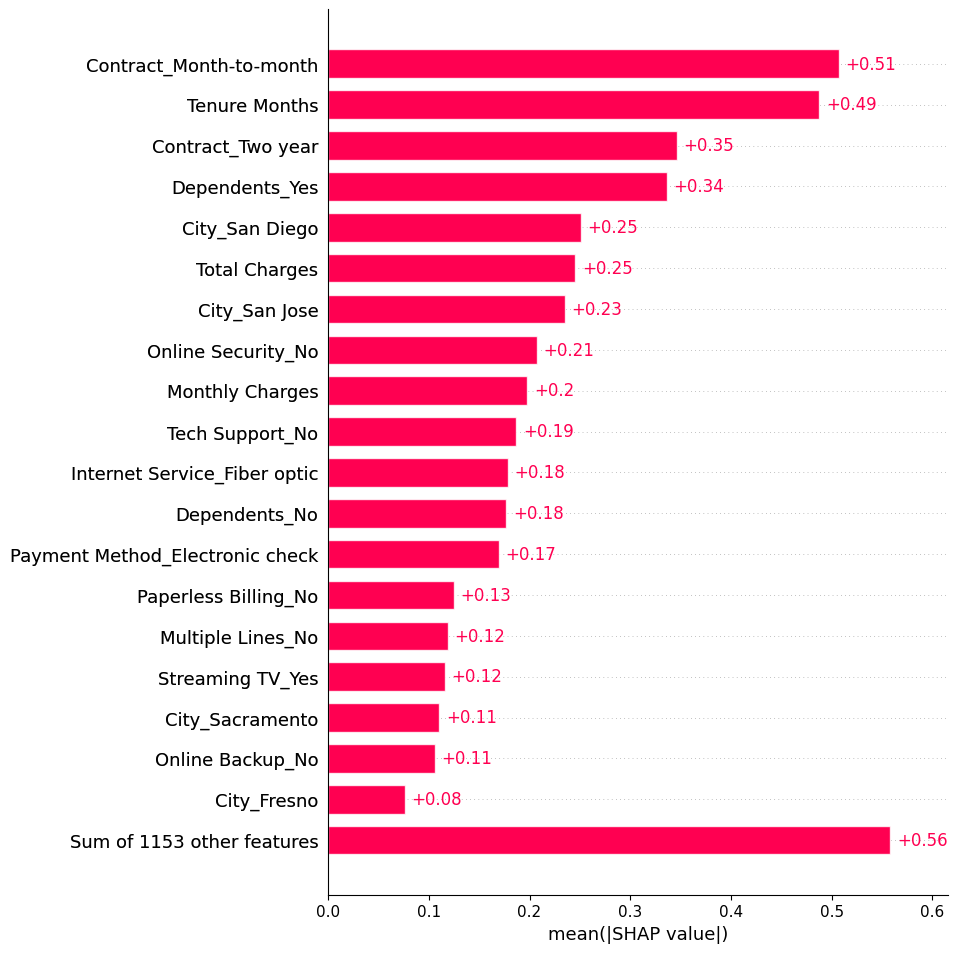

In [14]:
plt.figure(figsize=(10, 8))

shap.plots.bar(shap_values, max_display=20)

plt.show()

In [20]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)

plt.savefig(
    "../reports/figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [21]:
shap.plots.bar(shap_values, max_display=20, show=False)

plt.savefig(
    "../reports/figures/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [22]:
customer_index = 0

print("Selected Customer Index:", customer_index)

Selected Customer Index: 0


In [26]:
prediction_probability = model.predict_proba(
    X_test_processed.iloc[[customer_index]]
)[0, 1]

prediction = model.predict(
    X_test_processed.iloc[[customer_index]]
)[0]

print("=" * 40)
print(f"Customer Index      : {customer_index}")
print(f"Predicted Class     : {'Churn' if prediction == 1 else 'No Churn'}")
print(f"Churn Probability   : {prediction_probability:.2%}")
print("=" * 40)

Customer Index      : 0
Predicted Class     : No Churn
Churn Probability   : 27.88%


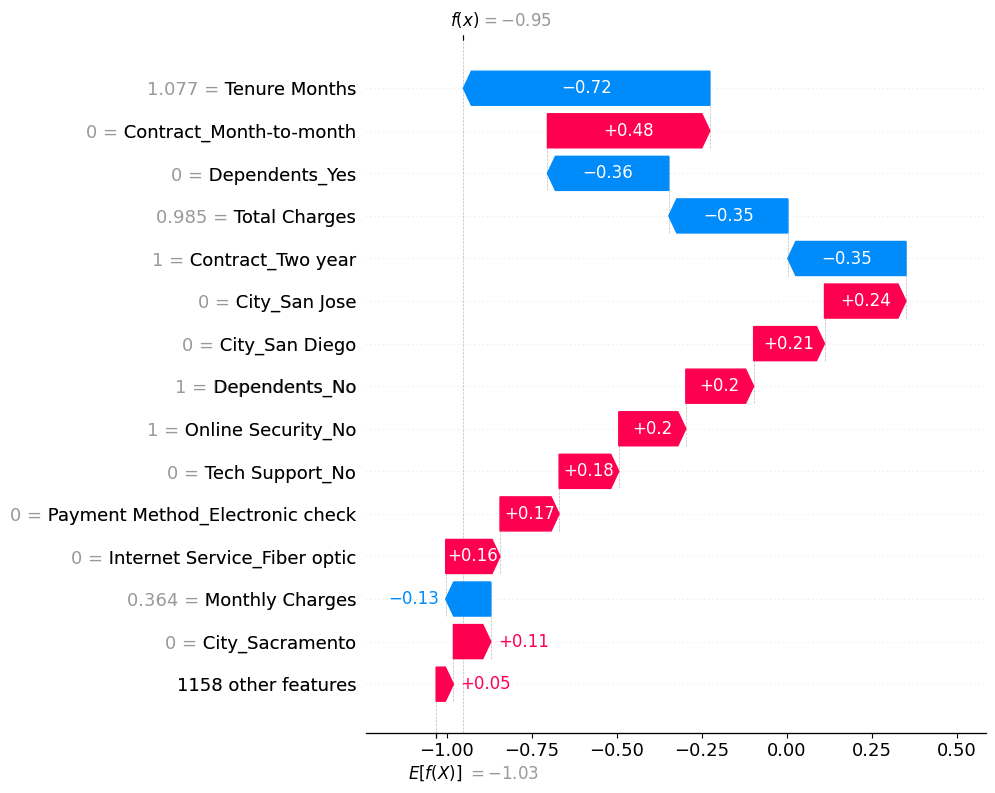

In [24]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=15
)

In [31]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=15,
    show=False
)

plt.savefig(
    "../reports/figures/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [27]:
shap.initjs()

shap.plots.force(
    shap_values[customer_index]
)

<Figure size 1000x600 with 0 Axes>

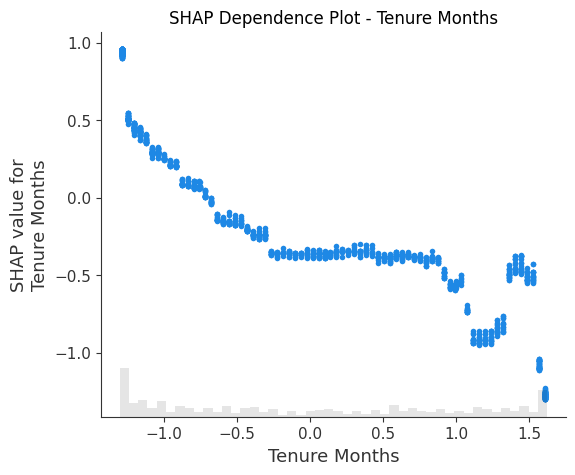

In [32]:
plt.figure(figsize=(10, 6))

shap.plots.scatter(
    shap_values[:, "Tenure Months"],
    show=False
)

plt.title("SHAP Dependence Plot - Tenure Months")

plt.savefig(
    "../reports/figures/shap_dependence_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x600 with 0 Axes>

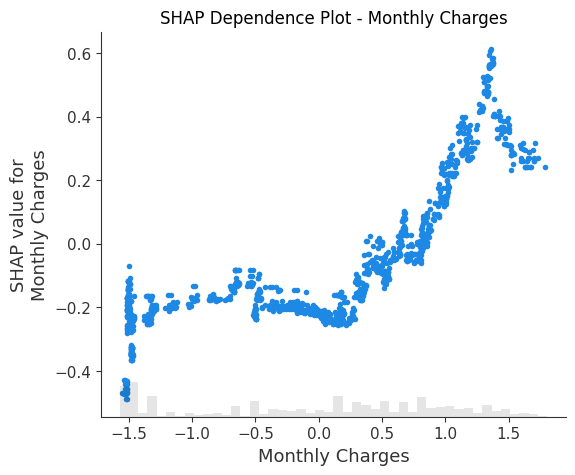

In [33]:
plt.figure(figsize=(10,6))

shap.plots.scatter(
    shap_values[:, "Monthly Charges"],
    show=False
)

plt.title("SHAP Dependence Plot - Monthly Charges")

plt.savefig(
    "../reports/figures/shap_dependence_monthly_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()